In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns
from PlanningDynamics import utils, plotting, graph
from PlanningDynamics.dataClass import nwbWrapper
from sklearn.linear_model import LinearRegression
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as sklearnPCA

fnames = utils.get_filenames()

def interpolate_colors(color1, color2, num_colors):
    cmap = LinearSegmentedColormap.from_list('custom_cmap', [color1, color2], N=num_colors)
    colors = [cmap(i) for i in range(num_colors)]
    return colors

choice_colors = interpolate_colors(color2="#ff0000", color1="#ff75ac", num_colors=4)
plan_colors = interpolate_colors(color2="#0073ff", color1="#69d9ff", num_colors=4)

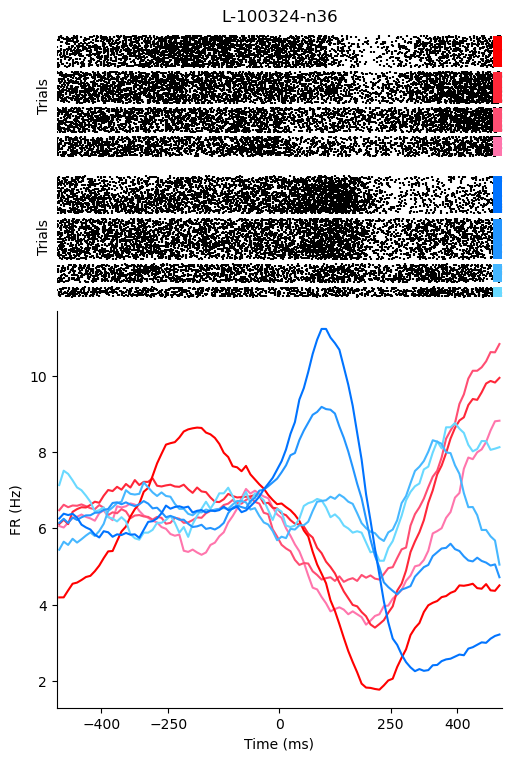

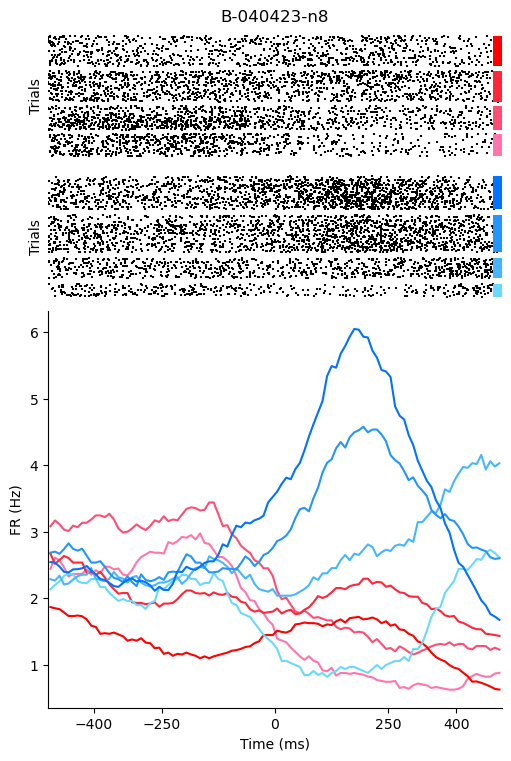

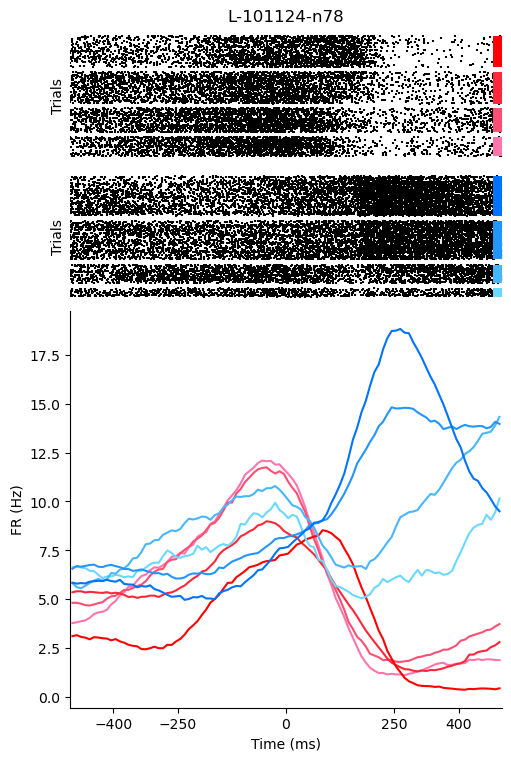

In [2]:
def choice_and_plan_value_psth(ax, data, unit):
    plan_data = data.get_plan_spikes(type="psth", min_duration=100, active_prob_threshold=0.1)
    values = utils.distance_to_value(data.choice_df.graph_distance.values)
    value_argsort = np.argsort(values)
    values = values[value_argsort]
    
    spikes = data.choice_spikes[value_argsort, :, unit]
    w = 75
    smoothed_spikes = utils.movmean(spikes, w)
    Y, X = np.where(spikes)
    for v in [1, 2, 3, 4]:
        idx = np.where(values == v)[0]
        if len(idx) == 0:
            continue
        t = np.arange(-500, 500)
        fr = smoothed_spikes[idx, :].mean(axis=0)*1000
        steps = np.arange(0, len(t), 10) + 5
        ax[2].plot(t[steps], fr[steps], label=f"Value {v}", c=choice_colors[v-1])
        y_idx = (Y >= idx[0])& (Y < idx[-1])
        buffer = 100
        ax[0].scatter(X[y_idx] - 500, Y[y_idx] + buffer*v, s=1, marker="|", c="k")
        ax[0].add_patch(Rectangle([480, Y[y_idx][0] + buffer*v], width=20, height=Y[y_idx][-1] - Y[y_idx][0], color=choice_colors[v-1], alpha=1, lw=0)) 
    
    values = utils.distance_to_value(plan_data["df"].graph_distance.values)
    value_argsort = np.argsort(values)
    values = values[value_argsort]
    spikes = plan_data["spikes"][value_argsort, :, unit]

    w = 75
    smoothed_spikes = utils.movmean(spikes, w)
    Y, X = np.where(spikes)
    for v in [1, 2, 3, 4]:
        idx = np.where(values == v)[0]
        if len(idx) == 0:
            continue
        t = np.arange(-500, 500)
        fr = smoothed_spikes[idx, :].mean(axis=0)*1000
        steps = np.arange(0, len(t), 10) + 5
        ax[2].plot(t[steps], fr[steps], label=f"Value {v}", c=plan_colors[v-1])
        y_idx = (Y >= idx[0])& (Y < idx[-1])
        buffer = 100
        ax[1].scatter(X[y_idx] - 500, Y[y_idx] + buffer*v, s=1, marker="|", c="k")
        ax[1].add_patch(Rectangle([480, Y[y_idx][0] + buffer*v], width=20, height=Y[y_idx][-1] - Y[y_idx][0], color=plan_colors[v-1], alpha=1, lw=0))

    for i in range(3):
        ax[i].set_xlim([-500, 500])
        
    ax[2].set_xlabel("Time (ms)")
    ax[0].set_ylabel("Trials")
    ax[1].set_ylabel("Trials")
    ax[2].set_ylabel("FR (Hz)")
    
def fig4a():
    def find_filename(date, f):
        for fname in f:
            if date in fname:
                return fname

    unit1 = ["100324", 36, "london"]
    unit2 = ["040423", 8, "bart"]
    unit3 = ["101124", 78, "london"]

    for unit in [unit1, unit2, unit3]:
        fname = find_filename(unit[0], fnames[unit[2]])
        data = nwbWrapper(fname, region="OFC")
        fig, ax = plt.subplots(3, 1, figsize=(5, 7.5), gridspec_kw={"height_ratios": [1, 1, 3]}, constrained_layout=True)
        choice_and_plan_value_psth(ax, data, unit=unit[1])

        sns.despine(ax=ax[2])
        sns.despine(ax=ax[0], left=True, bottom=True)
        sns.despine(ax=ax[1], left=True, bottom=True)
        for j in range(2):
            ax[j].set_xticks([])
            ax[j].set_yticks([])
        #ax[1].set_yticks([2, 7])
        ax[2].set_xticks([-400, -250, 0, 250, 400])
        ax[0].set_title("%s-%s-n%i" % (unit[2][0].upper(), unit[0], unit[1]))
        plt.show()

fig4a()

In [ ]:
np.random.seed(42)
from PlanningDynamics.subspaces import get_spikes, PCA 

def fit_pc_models(condition_averages):
    PC_models = {}
    for sbj in condition_averages:
        PC_models[sbj] = {}
        X_full = []
        for cond in ["choice", "plan"]:
            key = cond + "_avg"
            X = np.concat([a[key] for a in condition_averages[sbj]], axis=2)
            X_full.append(X)
            model = PCA(n_components=10, bin_size=150, step_size=10)
            model.fit(X)
            PC_models[sbj][cond] = model
        
        X_full = np.concat(X_full, axis=0)
        model = PCA(n_components=10, bin_size=150, step_size=10)
        model.fit(X_full)
        PC_models[sbj]["full"] = model
        
    # compute cross subspace alignment    
    for sbj in PC_models:
        choice, plan = PC_models[sbj]["choice"], PC_models[sbj]["plan"]
        def cross_model_alignment(model1, model2):
            Q = model1.model["pca"].components_
            C = model2.model["pca"].get_covariance()
            lam = model2.model["pca"].singular_values_
            alignment = np.diag(Q @ C @ Q.T).sum()/lam.sum()
            return alignment
        PC_models[sbj]["plan_to_choice_alignment"] = cross_model_alignment(choice, plan)
        PC_models[sbj]["choice_to_plan_alignment"] = cross_model_alignment(plan, choice)
        

    # compute null alignment indices    
    def random_basis(C, Q, S, n_components):
        v = np.random.normal(0, 1, size=(C.shape[0], n_components))
        M = np.dot(Q * np.sqrt(S), v)
        M = M / np.linalg.norm(M, 2, axis=0)
        M, _ = np.linalg.qr(M)
        return M

    from tqdm import trange
    for sbj in PC_models:
        choice_avg = np.concat([a["choice_avg"] for a in condition_averages[sbj]], axis=2)
        plan_avg = np.concat([a["plan_avg"] for a in condition_averages[sbj]], axis=2)
        full_avg = np.concat([choice_avg, plan_avg], axis=0)
        n_components = 10
        model = PCA(n_components=n_components, bin_size=150, step_size=10)
        model.fit(full_avg)
        
        n_iterations = 10000
        null_alignment = np.zeros((n_iterations, ))
        C = model.model["pca"].get_covariance()
        S, Q = np.linalg.eigh(C)

        for i in trange(n_iterations):
            M_1 = random_basis(C, Q, S, n_components=n_components)
            M_2 = random_basis(C, Q, S, n_components=n_components)
            null_alignment[i] = np.diag((M_2.T @ M_1) @ (M_1.T @ M_2)).sum()/n_components
        
        PC_models[sbj]["null_alignment"] = null_alignment
    return PC_models

condition_averages = utils.iterate_subjects(fnames, get_spikes)
PC_models = fit_pc_models(condition_averages)

Processing london: 100%|██████████| 7/7 [01:13<00:00, 10.43s/it]


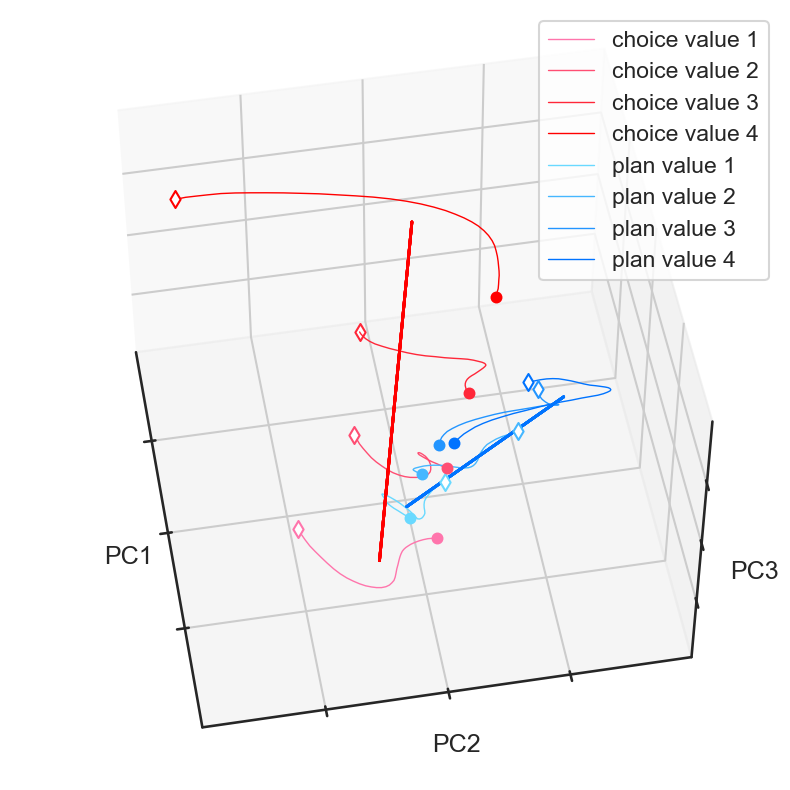

In [39]:
def fig4b(PC_models):
    sbj = "london"
    conditions = {}
    for i in range(4):
        conditions[i]  = "choice value " + str(i + 1)
        conditions[i + 4] = "plan value " + str(i + 1)
    model = PC_models[sbj]["full"]
    sns.set(style="ticks", context="talk", palette="tab10")

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    PCs = model.PCs.copy()

    l_start, l_end = 45, 85
    t_start = 50
    t_end = 80
    
    colors_all = np.vstack([choice_colors, plan_colors])

    for i in range(8):
        trace = utils.movmean(PCs[i, l_start:l_end, :].T, w=2).T
        c = colors_all[i]
        ax.plot(trace[:, 0], trace[:, 1], trace[:, 2], color=c, alpha=1, linestyle="-", lw=1, label=conditions[i])
        ax.scatter(trace[0, 0], trace[0, 1], trace[0, 2], color=c, s=50, alpha=1)
        ax.scatter(trace[-1, 0], trace[-1, 1], trace[-1, 2], s=75, alpha=1, marker="d", facecolor="white", edgecolor=c)

        mean_pcs_exe = PCs[:4, t_start:t_end, :].mean(axis=1)
        mean_pcs_plan = PCs[4:, t_start:t_end, :].mean(axis=1)    

        def plot_linear_regression(ax, mean_pcs, colors):
            model = LinearRegression().fit(mean_pcs[:, [0, 1]], mean_pcs[:, 2])
            exe_coef = model.coef_.copy()
            exe_intercept = model.intercept_

            X, Y = np.linspace(mean_pcs[0, 0], mean_pcs[3, 0]), np.linspace(mean_pcs[0, 1], mean_pcs[3, 1])
            Z = exe_coef[0] * X + exe_coef[1] * Y + exe_intercept
            ax.plot(X, Y, Z, color=colors[-1], lw=2)
            return

        plot_linear_regression(ax, mean_pcs_exe, choice_colors)
        plot_linear_regression(ax, mean_pcs_plan, plan_colors)

        ax.set_xlim([-20, 40])
        ax.set_ylim([-30, 30])
        ax.set_zlim([-30, 40])

        ax.set_xlabel("PC%i" % 1)
        ax.set_ylabel("PC%i" % 2)
        ax.set_zlabel("PC%i" % 3)

    ax.set_xticks([-5, 10, 25], labels=["", "", ""])
    ax.set_yticks([-30 + 15 , -30 + 30, -30 + 45], labels=["", "", ""])
    ax.set_zticks([-30 + 70/4, -30 + 140/4, -30 + 210/4], labels=["", "", ""])    
    ax.legend()
    # change view to rotate subspace plto
    ax.view_init(230, 10) 
    
    return fig, ax

fig, ax = fig4b(PC_models)
plt.show()

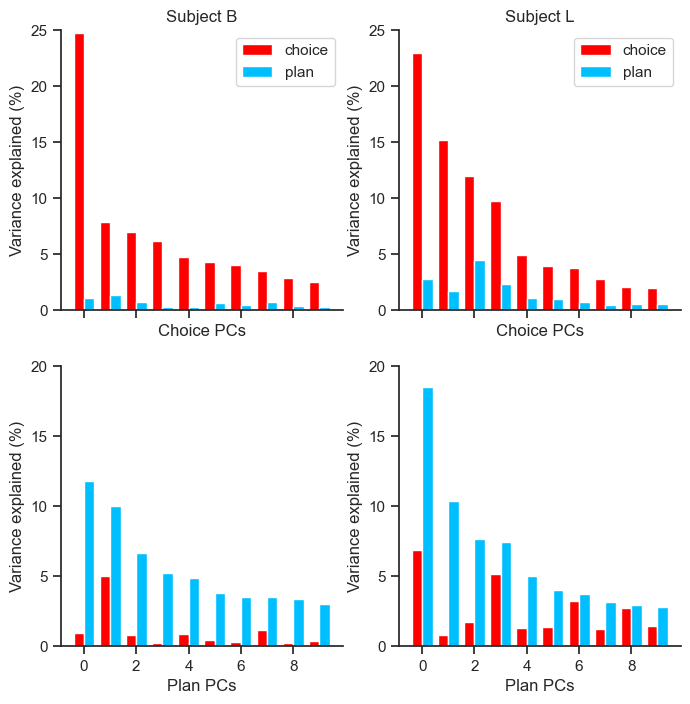

In [40]:
def fig4C(PC_models):
    sns.set(style="ticks")
    fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=False, sharex=True)
    sns.despine()

    for i, sbj in enumerate(PC_models):
        choice = PC_models[sbj]["choice"]
        plan = PC_models[sbj]["plan"]
        choice_to_choice = choice.projected_response(choice.X)
        plan_to_choice = choice.projected_response(plan.X)
        
        plan_to_plan = plan.projected_response(plan.X)
        choice_to_plan = plan.projected_response(choice.X)
        
        n_components = 10
        w = 0.4
        x_choice = np.arange(0, n_components) - w/2
        x_plan = np.arange(0, n_components) + w/2
        ax = axes[:, i]
        c_choice = "red"
        c_plan = "deepskyblue"
        
        # Projection into choice subspace
        ax[0].bar(x_choice, choice_to_choice["var_explained"]*100, width=w, label="choice", color=c_choice)
        ax[0].bar(x_plan, plan_to_choice["var_explained"]*100, width=w, label="plan", color=c_plan)
        ax[0].set_ylim([0, 25])
        ax[0].legend()
        ax[0].set_xlabel("Choice PCs")
        ax[0].set_title("Subject %s" % sbj[0].capitalize())
        
        # Projection into plan subspace
        ax[1].bar(x_choice, choice_to_plan["var_explained"]*100, width=w, label="choice", color=c_choice)
        ax[1].bar(x_plan, plan_to_plan["var_explained"]*100, width=w, label="plan", color=c_plan)
        ax[1].set_ylim([0, 20])
        ax[1].set_yticks([0, 5, 10, 15, 20])
        ax[1].set_xlabel("Plan PCs")
        ax[0].set_ylabel("Variance explained (%)")
        ax[1].set_ylabel("Variance explained (%)")
    return fig, ax 

fig4C(PC_models)
plt.show()

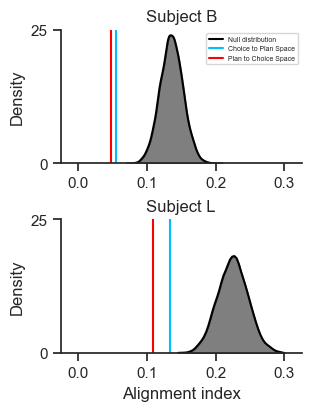

In [41]:
def fig4d(PC_models):
    sns.set(style="ticks")
    fig, ax = plt.subplots(2, 1, figsize=(3, 4), constrained_layout=True)

    from scipy.stats import gaussian_kde, ttest_ind
            
    for i, sbj in enumerate(PC_models):
        PC_models[sbj]["null_alignment"]
        kde = gaussian_kde(PC_models[sbj]["null_alignment"])
        if i == 0:
            x_values = np.linspace(0.07, 0.21, 1000)  # Define the range for x values
        else:
            x_values = np.linspace(0.145, 0.3)
        kde_values = kde(x_values)  # Get the density values
        ax[i].fill_between(x_values, 0, kde_values, color="black", alpha=0.5)
        ax[i].plot(x_values, kde_values, color="black", label="Null distribution")
        
        ax[i].axvline(PC_models[sbj]["choice_to_plan_alignment"], color="deepskyblue", linestyle="-", label="Choice to Plan Space")
        ax[i].axvline(PC_models[sbj]["plan_to_choice_alignment"], color="red", linestyle="-", label="Plan to Choice Space")
        
        ax[i].set_xlim([-0.025, 0.325])
        ax[i].set_ylim([0, 25])
        ax[i].set_yticks([0, 25])
        ax[i].set_xticks([0, 0.1, 0.2, 0.3])

        if i == 0:
            ax[i].legend(fontsize=5)
        ax[i].set_ylabel("Density")
        ax[i].set_title("Subject " + sbj[0].capitalize())
        
        if i == 1:
            ax[i].set_xlabel("Alignment index")
        sns.despine()
    return fig, ax 

fig4d(PC_models)
plt.show()